In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/Auto.csv"
df = pd.read_csv(url)
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


Perfect. ✅ Dataset structure clear hai.

🔍 What we learned
Rows    = 392
Columns = 9

And importantly:

mpg, displacement, acceleration → float64
cylinders, horsepower, weight, year, origin → int64
name → object
392/392 non-null for every column → currently no missing values
name is text, so we'll need to decide later whether to use or drop it.

So dataset is already relatively clean, but EDA ke baad preprocessing decisions lenge, blindly cleaning nahi karenge.

In [ ]:
df.shape

(392, 9)

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64

Duplicate Rows:
0


Excellent. ✅ Dataset quality check clean hai.

What we confirmed
Missing values: 0 across all 9 columns
Duplicate rows: 0
So currently imputation ya duplicate removal ki need nahi hai.

But remember: clean ≠ ready for modeling. Abhi hume distributions, outliers, relationships, feature selection etc. samajhne hain.

In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


Nice! 🔎 Ab describe() se dataset ki numerical picture kaafi clear ho gayi.

What we're seeing
🎯 mpg — our target
Mean = 23.45
Median = 22.75
Min = 9
Max = 46.6
Std = 7.81

So cars ki fuel efficiency kaafi vary karti hai — roughly 9 to 46.6 MPG.

Engine-related features

horsepower:

Mean ≈ 104.5
Range = 46–230

weight:

Mean ≈ 2978
Range = 1613–5140

displacement:

Mean ≈ 194.4
Range = 68–455

Ye ranges kaafi broad hain, so later scaling important ho sakti hai, especially depending on which model/features we use.

One interesting observation 👀

origin has values:

1, 2, 3

Ye actually categorical encoding hai, despite being stored as int64. We'll handle that properly during preprocessing rather than treating it blindly as a continuous numerical feature.

year is different — that's a genuine numerical/time-related feature.

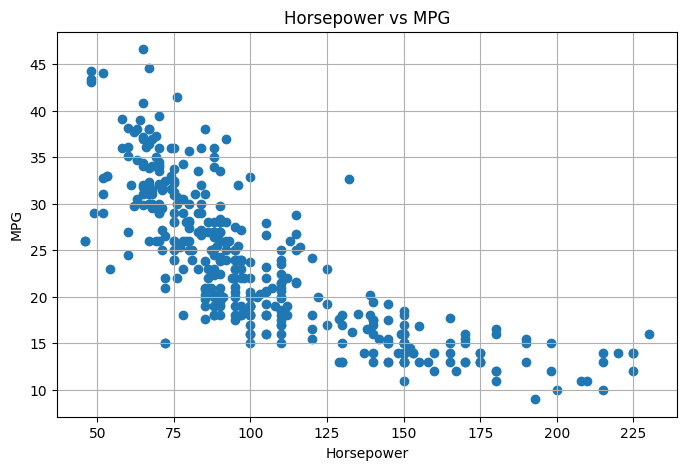

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.scatter(df["horsepower"], df["mpg"])

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)

plt.show()

Exactly — ye graph hamare experiment ke liye kaafi useful hai. 🔥

🔍 STEP 5 Output — Horsepower vs MPG

Graph ko dekho:

horsepower increase hone par mpg generally decrease ho raha hai.
Relationship negative hai.
Lekin ye perfectly straight-line pattern nahi hai.
Around 40–80 HP, MPG ka spread kaafi large hai.
Higher horsepower par MPG generally low ho jata hai, aur curve thoda flatten hota hua dikhta hai.

So visually:

Horsepower ↑ → MPG ↓, but relationship appears nonlinear.

Ye exactly woh situation hai jahan hum Linear Regression vs Polynomial Regression ko compare kar sakte hain.

⚠️ Lekin abhi hum ye conclude nahi karenge ki Polynomial better hai. Graph sirf hypothesis de raha hai. Actual conclusion test-set metrics se hoga.

In [ ]:
#MPG KA BAAKI FEATURES K SAATH RELATIONSHIP KITNA STRONG H

correlation = df.select_dtypes(include="number").corr()
correlation["mpg"].sort_values(ascending=False)

,mpg
mpg,1.000000
year,0.580541
origin,0.565209
acceleration,0.423329
cylinders,-0.777618
horsepower,-0.778427
displacement,-0.805127
weight,-0.832244


STEP 6 — Correlation ka interpretation

Tumhara output:

Feature	Correlation with MPG
year	+0.581
origin	+0.565
acceleration	+0.423
cylinders	−0.778
horsepower	−0.778
displacement	−0.805
weight	−0.832
Important observations

1. Weight → MPG

-0.832

Strong negative correlation.

Generally:

Weight ↑ → MPG ↓

2. Horsepower → MPG

-0.778

Again strong negative relationship, which matches the scatter plot we just saw.

3. Displacement → MPG

-0.805

Also strongly negative.

4. Year → MPG

+0.581

Newer cars in this dataset generally have better MPG.

⚠️ Important ML point

origin = 1, 2, 3 is an encoded categorical variable, so treating its Pearson correlation as a normal continuous numerical relationship isn't ideal.

We'll eventually decide how to handle it during preprocessing.

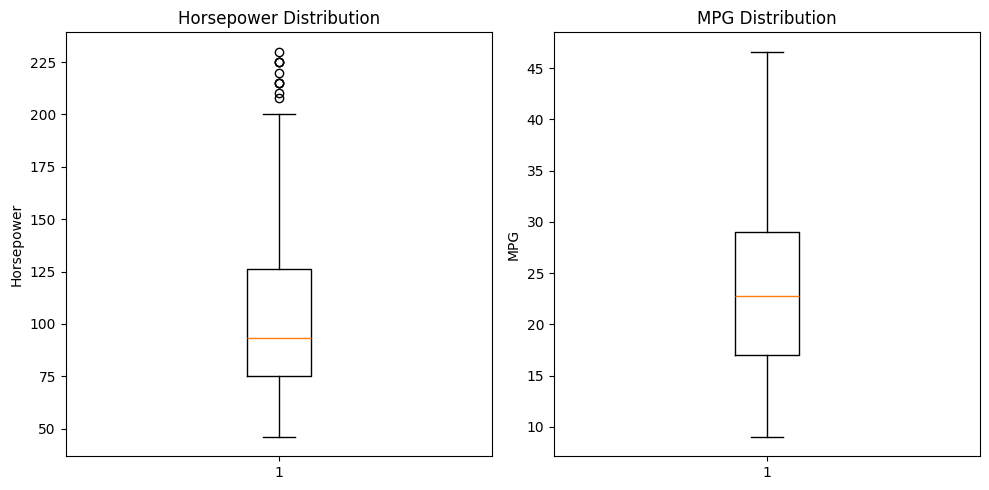

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df["horsepower"])
plt.title("Horsepower Distribution")
plt.ylabel("Horsepower")

plt.subplot(1, 2, 2)
plt.boxplot(df["mpg"])
plt.title("MPG Distribution")
plt.ylabel("MPG")

plt.tight_layout()
plt.show()

STEP 7 — Outlier Analysis
1. Horsepower

Tumhare graph mein upper side par kuch points 200–230 HP ke around outliers dikh rahe hain.

Lekin yahan ek important distinction hai:

Statistical outlier ≠ wrong data

200+ horsepower wali cars real-world mein perfectly possible hain. Dataset mein ye legitimate observations hain.

So:

❌ Inhe remove nahi karenge.

Agar hum inhe remove kar denge, toh model real-world variation ko learn nahi karega.

2. MPG

MPG ka boxplot relatively clean hai.

Range:

9 → 46.6 MPG

Koi particularly suspicious extreme point nahi dikh raha.

So:

❌ MPG values bhi remove nahi karenge.

🧠 Our preprocessing decision

Ab tak:

Missing values       → None
Duplicate rows       → None
Invalid values       → None identified
Outliers             → Keep

That's actually a good thing. 😎

Hum unnecessarily data clean nahi karenge.

In [ ]:
from sklearn.model_selection import train_test_split
X = df["horsepower"]
y = df["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 313
Testing samples: 79


Perfect. ✅ Split correctly hua:

313 samples → training
79 samples → testing
Total = 392

Ab hum actual modeling start karte hain. 🔥

In [ ]:
#BASELINE MODEL TRAINING : LINEAR REGRESSION

from sklearn.linear_model import LinearRegression

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Predictions
y_pred_linear = linear_model.predict(X_test)

print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_[0])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

Aha — good catch. 👍 Ye model ki problem nahi hai; X_train ka shape issue hai.

🔍 Error ka meaning

Scikit-learn keh raha hai:

Expected a 2-dimensional container, but got a Series.

For a single feature, X must be a DataFrame (2D), not a Series (1D).

Most likely tumhare notebook mein kahin ye hua:

X = df["horsepower"]

instead of:

X = df[["horsepower"]]
Difference samjho:
df["horsepower"]

→ Pandas Series → 1D

df[["horsepower"]]

→ Pandas DataFrame → 2D

Scikit-learn expects:

X → (samples, features)

So hamare case mein:

X → (392, 1)
🔧 STEP 9 — Fix the split

Ab ye poora cell dobara run karo:

In [ ]:
from sklearn.model_selection import train_test_split

# Feature and target
X = df[["horsepower"]]
y = df["mpg"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (313, 1)
X_test shape: (79, 1)
y_train shape: (313,)
y_test shape: (79,)


Perfect! ✅ Ab shapes exactly correct hain.

X_train → (313, 1)
X_test  → (79, 1)

y_train → (313,)
y_test  → (79,)

Matlab:

313 cars se model learn karega, aur 79 unseen cars par test hoga.

In [ ]:
from sklearn.linear_model import LinearRegression

# Create model
linear_model = LinearRegression()

# Train
linear_model.fit(X_train, y_train)

# Model parameters
print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_[0])

Intercept: 40.606097600118346
Coefficient: -0.16259724322918453


Perfect. 🔥 Ab Linear Regression ne actual relationship learn kar liya hai.

Tumhare model ke parameters:

Intercept  = 40.6061
Coefficient = -0.1626
🧠 Model ki equation

Linear Regression ne learn kiya:

MPG
^
=40.6061−0.1626×Horsepower

In [ ]:
y_pred_linear = linear_model.predict(X_test)
print(y_pred_linear[:10])

[29.38688782 21.90741463 30.85026301 29.22429057 26.62273468 28.41130436
 12.96456625 28.41130436 25.15935949 32.63883268]


Perfect. ✅ Ab hamare paas Linear Regression ki test predictions aa gayi hain.

Ye:

y_pred_linear

har test car ke liye predicted MPG hai.

For example, first prediction:

29.3869 MPG

Matlab corresponding test car ke horsepower ko dekhkar Linear Regression ne approximately 29.39 MPG predict kiya.

But ⚠️ prediction dekhkar model ki quality decide nahi kar sakte. Hume actual y_test ke saath compare karna padega.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(mse_linear)

r2_linear = r2_score(y_test, y_pred_linear)

print("LINEAR REGRESSION PERFORMACE METRICS:\n")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)


LINEAR REGRESSION PERFORMACE METRICS:

MAE : 3.782512710126959
MSE : 22.153237123863413
RMSE: 4.706722545876633
R²  : 0.5659681822256185


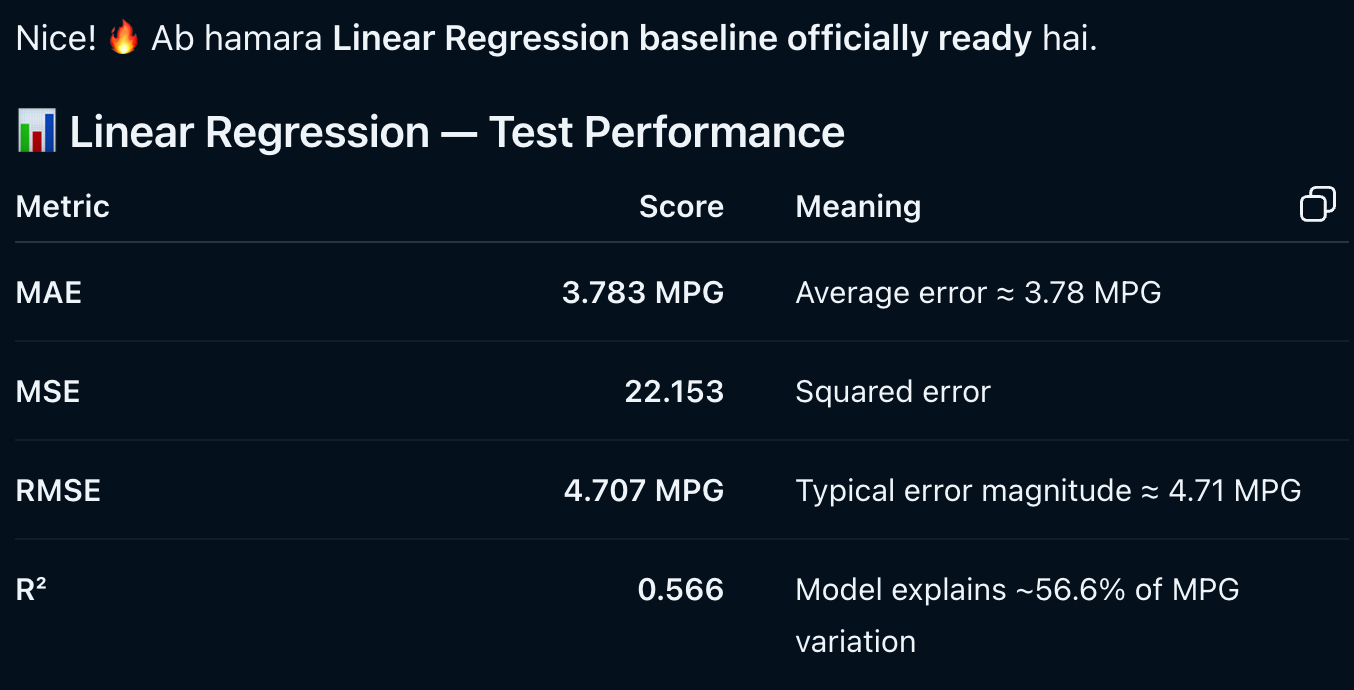

Interpretation

Our model:

$$ MPG = 40.606 - 0.1626(Horsepower) $$

has an R² of 0.566 on the unseen test set.

That means horsepower alone, using a straight-line relationship, captures a substantial portion of the variation in MPG, but there's still plenty of unexplained variation.

And this is exactly why our experiment gets interesting. 👀

Our EDA suggested that the horsepower → mpg relationship isn't perfectly linear.

So now the question is:

Can Polynomial Regression capture that nonlinear pattern better than this linear baseline?

We don't know yet — metrics will decide.

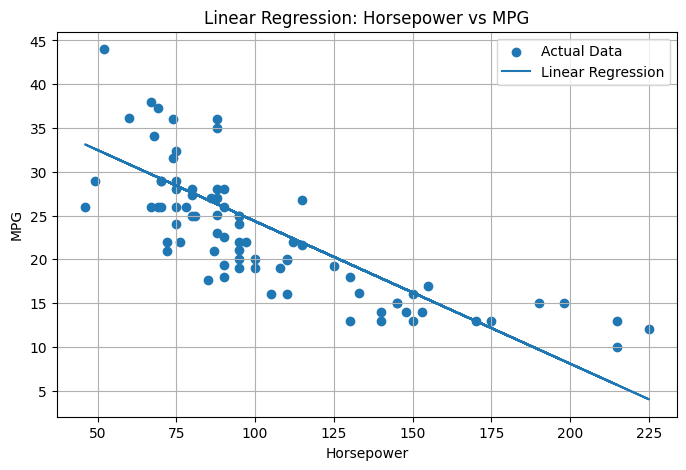

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test["horsepower"], y_test, label="Actual Data")

plt.plot(
    X_test["horsepower"],
    y_pred_linear,
    label="Linear Regression"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear Regression: Horsepower vs MPG")

plt.legend()
plt.grid(True)
plt.show()

Exactly. 👌 This graph makes the limitation of our baseline very visible.

🔍 STEP 12 — Linear Regression Visualization

The blue line is our learned model:

$$ \hat{MPG}=40.606-0.1626(Horsepower) $$
What do we notice?

The actual points clearly don't sit around a perfect straight-line pattern.

For example:

At lower horsepower, MPG has a large spread.
Around 70–100 HP, there is noticeable curvature/spread.
At higher horsepower, MPG decreases and appears to flatten somewhat.
The straight line is therefore a compromise across the entire dataset.

This visually supports our earlier hypothesis:

A linear relationship may not be flexible enough to capture the horsepower → MPG pattern.

But remember: visual appearance alone doesn't prove Polynomial Regression will perform better on unseen data. We'll let the test metrics decide. 🎯

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial transformer
poly = PolynomialFeatures(degree=2)

# Transform training and testing data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Polynomial X_train shape:", X_train_poly.shape)

print("\nFirst 5 transformed rows:")
print(X_train_poly[:5])

Original X_train shape: (313, 1)
Polynomial X_train shape: (313, 3)

First 5 transformed rows:
[[1.000e+00 1.100e+02 1.210e+04]
 [1.000e+00 9.200e+01 8.464e+03]
 [1.000e+00 9.700e+01 9.409e+03]
 [1.000e+00 1.500e+02 2.250e+04]
 [1.000e+00 6.400e+01 4.096e+03]]


Perfect. 🔥 This output is exactly what we expected.

🔍 STEP 13 — What happened?

Original:

X_train shape = (313, 1)

We had only:

horsepower

After PolynomialFeatures(degree=2):

X_train_poly shape = (313, 3)

Because it created:

[1, horsepower, horsepower²]

For example, your first row:

[1.000e+00 1.100e+02 1.210e+04]

means:

1
110
110² = 12,100

Exactly right. ✅

So now our model can learn:

$$ MPG=\beta_0+\beta_1X+\beta_2X^2 $$

instead of being restricted to a straight line.

In [ ]:
poly_model = LinearRegression()

# Train polynomial model
poly_model.fit(X_train_poly, y_train)

# Predictions
y_pred_poly = poly_model.predict(X_test_poly)

print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)

Intercept: 58.212944359179374
Coefficients: [ 0.         -0.48445839  0.0012949 ]


Perfect! 🔥 Ab Polynomial Regression ne actual curved relationship learn kar liya hai.

Tumhara output:

Intercept: 58.212944359179374

Coefficients:
[ 0.         -0.48445839  0.0012949 ]
🧠 Let's decode it

Recall our transformed features:

[1, X, X²]

where:

X = horsepower

The LinearRegression model has its own intercept, so the first coefficient corresponding to the added 1 column is:

0

and actual learned coefficients are:

β₁ = -0.48445839
β₂ =  0.00129490

Therefore our polynomial equation is:

$$ \boxed{ MPG = 58.2129 - 0.48446(Horsepower) \+ 0.0012949(Horsepower)^2 } $$
🔥 Notice the difference

Linear model:

$$ MPG = 40.6061 - 0.1626X $$

Polynomial model:

$$ MPG = 58.2129 - 0.48446X + 0.0012949X^2 $$

The crucial new term is:

$$ \boxed{0.0012949X^2} $$

That's what allows the model to bend instead of remaining a straight line.

Because the coefficient of \(X^2\) is positive, the curve bends upward mathematically.

One subtle but important point

Don't interpret -0.48446 as simply:

"Every 1 HP decreases MPG by 0.484."

❌ That's not correct anymore.

Because MPG now depends on both X and X²:

$$ MPG=f(X,X^2) $$

The effect of horsepower changes depending on the horsepower level. That's precisely the flexibility we wanted from Polynomial Regression. 🎯

In [ ]:
#STEP 15 — Evaluate Polynomial Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("POLYNOMIAL REGRESSION PERFORMANCE METRICS")
print("------------------------------------------")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

POLYNOMIAL REGRESSION PERFORMANCE METRICS
------------------------------------------
MAE : 3.264280823763114
MSE : 18.416967796017616
RMSE: 4.291499481069247
R²  : 0.6391701147013347


🔥 Now we have the actual result! This is exactly the experiment we wanted to perform.

📊 Linear vs Polynomial — Test Set

| Metric     | Linear Regression | Polynomial Regression |   Change |
| ---------- | ----------------: | --------------------: | -------: |
| **MAE ↓**  |            3.7825 |            **3.2643** | ↓ 0.5182 |
| **MSE ↓**  |           22.1532 |           **18.4170** | ↓ 3.7363 |
| **RMSE ↓** |            4.7067 |            **4.2915** | ↓ 0.4152 |
| **R² ↑**   |            0.5660 |            **0.6392** | ↑ 0.0732 |


🧠 What happened?

Polynomial Regression improved every single test metric.

MAE:

3.78 → 3.26 MPG

So average absolute prediction error decreased.

RMSE:
4.71 → 4.29 MPG

So the model also reduced the impact of larger prediction errors.

R²:

56.6% → 63.9%

The polynomial model explains substantially more of the variation in unseen MPG values for this particular train/test split.

🎯 So what did we learn?

Our original hypothesis was:

The horsepower → MPG relationship isn't perfectly linear.

Our experiment supports that hypothesis.

The linear model was:

$$ MPG=40.6061-0.1626X $$

while the degree-2 polynomial model was:

MPG=58.2129−0.48446X+0.0012949X
2

The additional \(X^2\) term gives the model the ability to represent curvature.

But there's an important ML lesson here 👇

We didn't say Polynomial Regression is always better than Linear Regression.

We can only say:

On this dataset, using horsepower as the single feature, degree-2 Polynomial Regression achieved better test-set metrics than Linear Regression on our fixed 80/20 split.

That's the scientifically correct conclusion. 💯

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


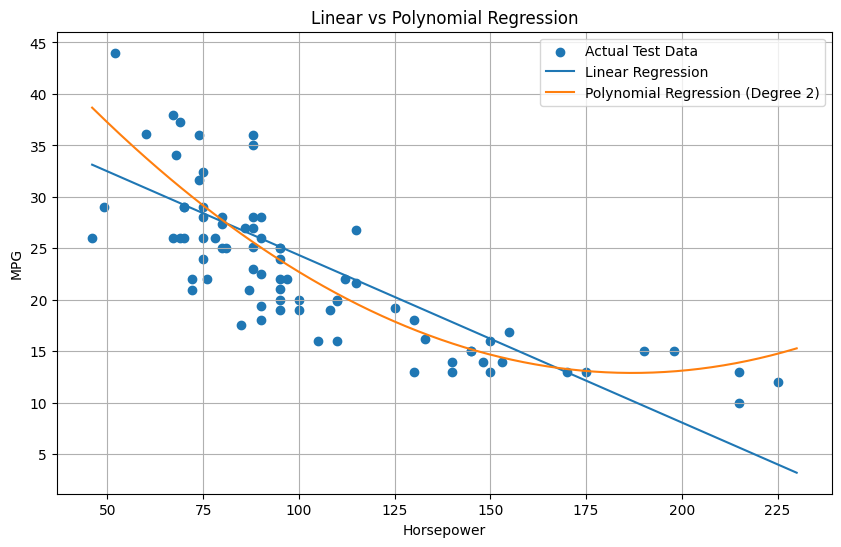

In [ ]:
#STEP16 — Visual Comparison

#Now let's actually see the difference between the two models.
# Create smooth horsepower values
X_curve = np.linspace(
    X["horsepower"].min(),
    X["horsepower"].max(),
    300
).reshape(-1, 1)

# Linear predictions
y_curve_linear = linear_model.predict(X_curve)

# Polynomial predictions
X_curve_poly = poly.transform(X_curve)
y_curve_poly = poly_model.predict(X_curve_poly)

# Plot
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["horsepower"],
    y_test,
    label="Actual Test Data"
)

plt.plot(
    X_curve,
    y_curve_linear,
    label="Linear Regression"
)

plt.plot(
    X_curve,
    y_curve_poly,
    label="Polynomial Regression (Degree 2)"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear vs Polynomial Regression")

plt.legend()
plt.grid(True)
plt.show()

Exactly! 🔥 This graph is the visual proof of what our metrics were telling us.

🔍 STEP 16 — Interpreting the comparison

You can clearly see the difference:

🔵 Linear Regression

The blue line is completely straight:

$$ \hat{y}=40.606-0.1626x $$

At higher horsepower, it keeps decreasing at the same rate.

But look at the actual points around 170–230 HP — the MPG values aren't continuing downward as steeply as the blue line predicts.

That's one limitation of the linear assumption.

🟠 Polynomial Regression — Degree 2

The orange curve can bend:

$$ \hat{y}=58.213-0.4845x+0.001295x^2 $$

Notice how it:

decreases rapidly at lower horsepower
gradually flattens
bends upward slightly at the high end

That curvature is exactly what the \(X^2\) term allows.

And this agrees with our test metrics:

Linear       R² = 0.5660
Polynomial   R² = 0.6392

So in our experiment, degree-2 polynomial captured the relationship better on the test set.

⚠️ But here's an important observation

Look at the orange curve at the extreme high-horsepower region.

It starts bending upward.

That may or may not represent the true underlying relationship. We only have relatively few observations there.

This is where polynomial degree selection becomes important.

If we keep increasing the degree:

Degree 1 → straight line
Degree 2 → simple curve
Degree 3 → more flexible
Degree 4 → even more flexible
...
Degree 15 → potentially crazy curve 🤯

Too much flexibility can lead to overfitting.

## 🚀 STEP 17 — Degree Comparison

Now we're going to run a **proper experiment**.

We'll train Polynomial Regression models with different polynomial degrees:

| Degree |
|--------|
| Degree 1 |
| Degree 2 |
| Degree 3 |
| Degree 4 |
| Degree 5 |
| Degree 6 |
| Degree 7 |
| Degree 8 |
| Degree 9 |
| Degree 10 |

And we'll compare **train vs test performance**.

This is much more educational than simply saying:

> **"Degree 2 is better."**

By comparing different degrees, we can understand:

- 📈 **Underfitting** — when the model is too simple
- 🎯 **Good fit** — when the model generalizes well
- 📉 **Overfitting** — when the model performs well on training data but poorly on unseen test data

This experiment will help us understand **why choosing the polynomial degree matters**.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

degrees = range(1, 11)

results = []

for degree in degrees:

    # Polynomial transformation
    poly_temp = PolynomialFeatures(degree=degree)

    X_train_temp = poly_temp.fit_transform(X_train)
    X_test_temp = poly_temp.transform(X_test)

    # Model
    model_temp = LinearRegression()
    model_temp.fit(X_train_temp, y_train)

    # Predictions
    train_pred = model_temp.predict(X_train_temp)
    test_pred = model_temp.predict(X_test_temp)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results.append([
        degree,
        train_rmse,
        test_rmse,
        train_r2,
        test_r2
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Degree",
        "Train_RMSE",
        "Test_RMSE",
        "Train_R2",
        "Test_R2"
    ]
)

results_df

,Degree,Train_RMSE,Test_RMSE,Train_R2,Test_R2
0,1,4.947238,4.706723,0.612119,0.565968
1,2,4.382307,4.291499,0.695647,0.639170
2,3,4.375361,4.296541,0.696611,0.638322
3,4,4.373350,4.274135,0.696890,0.642084
4,5,4.317873,4.228123,0.704531,0.649749
5,6,4.336854,4.262755,0.701927,0.643988
6,7,4.339464,4.274863,0.701569,0.641962
7,8,4.330074,4.278198,0.702859,0.641403
8,9,4.344415,4.298184,0.700887,0.638045
9,10,4.413032,4.351681,0.691364,0.628979


# 🔥 Excellent. Ab experiment aur interesting ho gaya — **Degree 2 best nahi nikla!**

Tumhare results ko properly read karte hain.

## 📊 Degree Comparison

| Degree | Train RMSE ↓ | Test RMSE ↓ | Train R² ↑ | Test R² ↑ |
|---:|---:|---:|---:|---:|
| 1 | 4.947 | 4.707 | 0.612 | 0.566 |
| 2 | 4.382 | 4.291 | 0.696 | 0.639 |
| 3 | 4.375 | 4.297 | 0.697 | 0.638 |
| 4 | 4.373 | **4.274** | 0.697 | 0.642 |
| **5** | **4.318** | **4.228** | **0.705** | **0.650** |
| 6 | 4.337 | 4.263 | 0.702 | 0.644 |
| 7 | 4.339 | 4.275 | 0.702 | 0.642 |
| 8 | 4.330 | 4.278 | 0.703 | 0.641 |
| 9 | 4.344 | 4.298 | 0.701 | 0.638 |
| 10 | 4.413 | 4.352 | 0.691 | 0.629 |

### 🎯 The Key Result

Our original **Linear Regression**:

```text
Test RMSE = 4.707
Test R²   = 0.566
**Degree-2:**

```text
Test RMSE = 4.291
Test R²   = 0.639
```

But **Degree-5** did even better:

```text
Test RMSE = 4.228
Test R²   = 0.650
```

So for **this particular train/test split**, Degree 5 has the **lowest test RMSE** and **highest test R²** among the degrees we tested.

---

# 🧠 And now comes the really important ML lesson

Look at the progression:

```text
Degree 1
   ↓
Test RMSE = 4.707

Degree 2
   ↓
4.291

Degree 3
   ↓
4.297

Degree 4
   ↓
4.274

Degree 5
   ↓
4.228  ← lowest

Degree 6+
   ↓
Performance starts getting worse
```

This is the beginning of the classic:

**Underfitting → Better Fit → Overfitting**

At higher degrees, notice something interesting:

### Training performance can remain very good

For example:

```text
Degree 8
Train R² = 0.703
Test R²  = 0.641
```

And:

```text
Degree 10
Train R² = 0.691
Test R²  = 0.629
```

The model is becoming more complex, but **test performance isn't improving anymore**.

That's the warning sign we wanted to observe.

---

# ⚠️ One Important Correction to Our Earlier Conclusion

Earlier we said **Degree 2 improved over Linear Regression**.

That's true.

But after testing multiple degrees, we can now say something more precise:

> **Polynomial features improved the test performance over the linear baseline, and among degrees 1–10 tested on this fixed split, Degree 5 produced the lowest test RMSE and highest test R².**

We shouldn't simply say:

> **"Higher degree = better."**

Clearly, after Degree 5, that isn't happening.

```
```


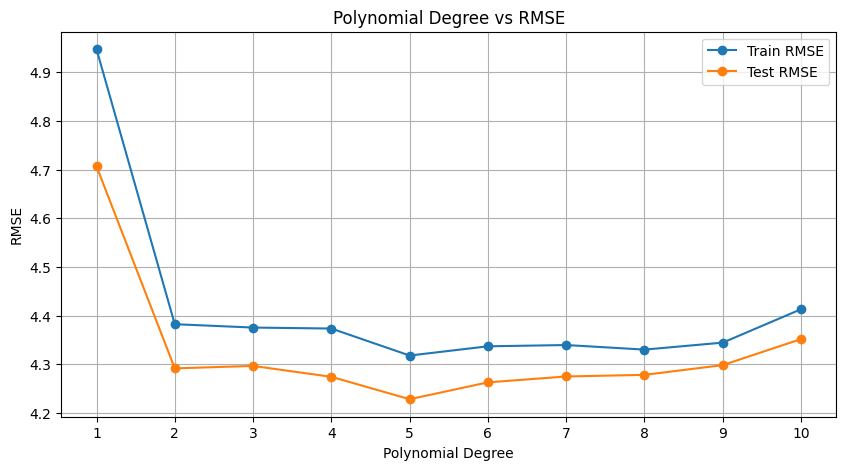

In [ ]:
#🚀 STEP 18 — Visualize Degree vs Performance

#Now let's make this pattern visually obvious.
plt.figure(figsize=(10, 5))

plt.plot(
    results_df["Degree"],
    results_df["Train_RMSE"],
    marker="o",
    label="Train RMSE"
)

plt.plot(
    results_df["Degree"],
    results_df["Test_RMSE"],
    marker="o",
    label="Test RMSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Polynomial Degree vs RMSE")

plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)

plt.show()

# 📈 STEP 18 — Degree vs RMSE

Exactly! 🔥 **This graph nicely shows the model-complexity story.**

Look at the **orange Test RMSE** line:

```text
Degree 1  → 4.707
Degree 2  → 4.291
Degree 3  → 4.297
Degree 4  → 4.274
Degree 5  → 4.228  ← lowest
Degree 6  → 4.263
Degree 7  → 4.275
Degree 8  → 4.278
Degree 9  → 4.298
Degree 10 → 4.352

So the test error:

falls → reaches minimum around Degree 5 → starts rising.

That's the behavior we wanted to observe. 🎯

🧠 Why does this happen?

At Degree 1, the model is too restrictive:

Straight line
    ↓
Cannot capture curvature
    ↓
Higher error

As we increase the degree:

Degree 1 → 2 → 3 → 4 → 5
                     ↓
             More flexibility
                     ↓
             Better test fit

But after Degree 5:

Degree 6 → 7 → 8 → 9 → 10
                    ↓
          Extra complexity
                    ↓
       Test performance worsens

This is the overfitting direction.

🔥 One Subtle Observation

Notice that Train RMSE and Test RMSE don't behave identically.

For example:

Degree 5:
Train RMSE = 4.318
Test RMSE  = 4.228

That's actually fine.

A test RMSE slightly lower than train RMSE can happen because the particular test split is somewhat easier than the training split.

It doesn't automatically mean leakage or a problem.

The important thing is the overall pattern across degrees.

🎯 Our Experiment So Far

We have now demonstrated:

Linear Regression
Test RMSE = 4.707
Test R²   = 0.566
Polynomial Regression — Degree 2
Test RMSE = 4.291
Test R²   = 0.639
Polynomial Regression — Degree 5
Test RMSE = 4.228
Test R²   = 0.650

So polynomial features gave our model additional flexibility, and Degree 5 was the strongest among Degrees 1–10 on this particular holdout split.



🚀 STEP 19 — Final Benchmark

Ab ek clean final comparison banate hain.

We'll compare:

Linear Regression
vs
Best Polynomial Regression (Degree 5)

Run:

In [ ]:
# Train final degree-5 polynomial model

poly5 = PolynomialFeatures(degree=5)

X_train_poly5 = poly5.fit_transform(X_train)
X_test_poly5 = poly5.transform(X_test)

poly5_model = LinearRegression()

poly5_model.fit(X_train_poly5, y_train)

y_pred_poly5 = poly5_model.predict(X_test_poly5)


# Evaluation

mae_poly5 = mean_absolute_error(y_test, y_pred_poly5)
mse_poly5 = mean_squared_error(y_test, y_pred_poly5)
rmse_poly5 = np.sqrt(mse_poly5)
r2_poly5 = r2_score(y_test, y_pred_poly5)


# Final comparison

comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Linear Regression": [
        mae_linear,
        mse_linear,
        rmse_linear,
        r2_linear
    ],
    "Polynomial Regression (Degree 5)": [
        mae_poly5,
        mse_poly5,
        rmse_poly5,
        r2_poly5
    ]
})

comparison

,Metric,Linear Regression,Polynomial Regression (Degree 5)
0,MAE,3.782513,3.295583
1,MSE,22.153237,17.877028
2,RMSE,4.706723,4.228123
3,R²,0.565968,0.649749


# 🏁 Final Benchmark

Yes! 🔥 **Final benchmark complete.** Ab hum is experiment ko properly close kar sakte hain.

## 📊 Final Benchmark

| Metric | Linear Regression | Polynomial Regression (Degree 5) | Improvement |
|---|---:|---:|---:|
| **MAE ↓** | 3.7825 | **3.2956** | ~12.9% lower |
| **MSE ↓** | 22.1532 | **17.8770** | ~19.3% lower |
| **RMSE ↓** | 4.7067 | **4.2281** | ~10.2% lower |
| **R² ↑** | 0.5660 | **0.6497** | +0.0838 |

So on our **79-sample test set**, Degree-5 Polynomial Regression performed better on **all four metrics**.

---

# 🧠 What Does That Actually Mean?

Our Linear Regression assumed:

$$
MPG = \beta_0 + \beta_1X
$$

Basically:

> **One constant slope.**

Polynomial Regression allowed:

$$
MPG = \beta_0 + \beta_1X + \beta_2X^2 + \cdots + \beta_5X^5
$$

So the model could represent a **curved relationship** between horsepower and MPG.

And our experiment showed that this additional flexibility helped on the held-out test set.

---

# 🎯 The Most Important Lesson

Don't take away:

> ❌ **"Polynomial Regression is better than Linear Regression."**

Take away:

> ✅ **"When the relationship between the feature and target is nonlinear, polynomial features can allow a linear estimator to model that curvature more effectively."**

And our experiment demonstrated exactly that.

---

# 🧪 We Also Discovered Something Important About Degree

Our degree experiment was:

```text
Degree 1  → RMSE 4.707
Degree 2  → RMSE 4.291
Degree 3  → RMSE 4.297
Degree 4  → RMSE 4.274
Degree 5  → RMSE 4.228  ← lowest
Degree 6  → RMSE 4.263
Degree 7  → RMSE 4.275
Degree 8  → RMSE 4.278
Degree 9  → RMSE 4.298
Degree 10 → RMSE 4.352

So increasing polynomial degree didn't continuously improve the model.

Instead:

                    Best
                     ↓
Underfit → Improve → Degree 5 → Degradation
   1       2  3  4      5       6  7  8  9  10

That's the practical lesson behind model complexity and overfitting.

⚠️ One Important Limitation of Our Experiment

We selected Degree 5 based on the same test set that we're using for final reporting.

For a rigorous ML workflow, that's not ideal.

Normally we'd do:

Training data
     ↓
Cross-validation
     ↓
Choose polynomial degree
     ↓
Final model
     ↓
ONE untouched test set
     ↓
Final evaluation

This prevents us from indirectly tuning the model to the test set.

So for learning Polynomial Regression, our experiment is excellent.

For a production/research-grade benchmark, we'd use cross-validation + a final untouched test set.

🧠 Your Complete Learning Workflow

You just went through a pretty realistic regression workflow:

Real Dataset
     ↓
EDA
     ↓
Missing Value Check
     ↓
Duplicate Check
     ↓
Statistical Analysis
     ↓
Correlation Analysis
     ↓
Outlier Analysis
     ↓
Feature Selection
     ↓
Train/Test Split
     ↓
Linear Regression
     ↓
Baseline Metrics
     ↓
Polynomial Features
     ↓
Polynomial Regression
     ↓
Degree Tuning
     ↓
Underfitting / Overfitting Analysis
     ↓
Final Benchmark

And the core takeaway:

Linear Regression

Good when the relationship is approximately linear.

Polynomial Regression

Useful when the relationship is nonlinear but can reasonably be represented by a polynomial curve.

Degree Selection

More complexity ≠ automatically better.

The goal is to find a level of complexity that captures the underlying pattern while still generalizing well to unseen data.

💯 Final Takeaway

You've now understood Polynomial Regression not just as:

PolynomialFeatures → LinearRegression → predict

but as an actual ML modeling process:

Observe the data
      ↓
Identify possible nonlinearity
      ↓
Build a linear baseline
      ↓
Add polynomial features
      ↓
Train the model
      ↓
Compare degrees
      ↓
Measure train vs test performance
      ↓
Understand underfitting / overfitting
      ↓
Evaluate the final model

That's a solid understanding of Polynomial Regression. 🚀